# Exercise 3

In this exercise, you will analyse a dataset obtained from the London transport system (TfL). The data is in a filled called `tfl_readership.csv` (comma-separated-values format).  As in Exercise 2, we will load and view the data using  `pandas`. 

In [174]:
# If you are running this on Google Colab, uncomment and run the following lines; otherwise ignore this cell
# from google.colab import drive
# drive.mount('/content/drive')

In [175]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [176]:
# Load data
df_tfl = pd.read_csv('tfl_ridership.csv')
# If running on Google Colab change path to '/content/drive/MyDrive/IB-Data-Science/Exercises/tfl_ridership.csv'

df_tfl.head(13)

,Year,Period,Start,End,Days,Bus cash (000s),Bus Oyster PAYG (000s),Bus Contactless (000s),Bus One Day Bus Pass (000s),Bus Day Travelcard (000s),...,Tube Contactless (000s),Tube Day Travelcard (000s),Tube Season Travelcard (000s),Tube Other incl free (000s),Tube Total (000s),TfL Rail (000s),Overground (000s),DLR (000s),Tram (000s),Air Line (000s)
0,2000/01,P 01,01 Apr '00,29 Apr '00,29d,884,0,0,210,231,...,0,655,1066,200,2509,0,0,96,45.8,0.0
1,2000/01,P 02,30 Apr '00,27 May '00,28d,949,0,0,214,205,...,0,605,1168,217,2598,0,0,93,46.5,0.0
2,2000/01,P 03,28 May '00,24 Jun '00,28d,945,0,0,209,221,...,0,650,1154,212,2623,0,0,98,47.1,0.0
3,2000/01,P 04,25 Jun '00,22 Jul '00,28d,981,0,0,216,241,...,0,708,1196,214,2761,0,0,105,50.8,0.0
4,2000/01,P 05,23 Jul '00,19 Aug '00,28d,958,0,0,225,248,...,0,730,1165,165,2643,0,0,103,50.3,0.0
5,2000/01,P 06,20 Aug '00,16 Sep '00,28d,984,0,0,243,236,...,0,702,1164,151,2608,0,0,100,49.2,0.0
6,2000/01,P 07,17 Sep '00,14 Oct '00,28d,1001,0,0,205,216,...,0,639,1286,196,2763,0,0,107,48.8,0.0
7,2000/01,P 08,15 Oct '00,11 Nov '00,28d,979,0,0,199,221,...,0,668,1298,220,2819,0,0,113,51.5,0.0
8,2000/01,P 09,12 Nov '00,09 Dec '00,28d,971,0,0,184,212,...,0,640,1302,242,2839,0,0,114,54.0,0.0
9,2000/01,P 10,10 Dec '00,06 Jan '01,28d,912,0,0,192,211,...,0,631,993,195,2359,0,0,90,55.3,0.0


Each row of our data frame represents the average daily ridership over a 28/29 day period for various types of transport and tickets (bus, tube etc.).  We have used the `.head()` command to display the top 13 rows of the data frame (corresponding to one year).  Focusing on the "Tube Total" column, notice the dip in ridership in row 9 (presumably due to Christmas/New Year's), and also the slight dip during the summer (rows 4,5).

In [177]:
#df_tfl.sample(3)  #random sample of 3 rows
df_tfl.tail(3)  #last 3 rows

,Year,Period,Start,End,Days,Bus cash (000s),Bus Oyster PAYG (000s),Bus Contactless (000s),Bus One Day Bus Pass (000s),Bus Day Travelcard (000s),...,Tube Contactless (000s),Tube Day Travelcard (000s),Tube Season Travelcard (000s),Tube Other incl free (000s),Tube Total (000s),TfL Rail (000s),Overground (000s),DLR (000s),Tram (000s),Air Line (000s)
242,2018/19,P 09,11 Nov '18,08 Dec '18,28d,0,1110,1089,0,41,...,1399,249,1017,334,4221,996,557,355,84.1,2.6
243,2018/19,P 10,09 Dec '18,05 Jan '19,28d,0,1001,949,0,38,...,1110,242,632,259,3279,750,414,270,66.3,3.2
244,2018/19,P 11,06 Jan '19,02 Feb '19,28d,0,1036,1075,0,30,...,1310,204,924,305,3809,929,517,333,79.3,2.3


The dataframe contains $N=245$ counting periods (of 28/29 days each) from 1 April 2000 to  2 Feb 2019. We now define a numpy array consisting of the values in the ' Tube Total (000s)' column:

In [178]:
yvals = np.array(df_tfl['Tube Total (000s)'])
N = np.size(yvals)
xvals = np.linspace(1,N,N) #an array containing the values 1,2....,N


We now have a time series consisting of points $(x_i,y_i)$, for $i = 1, \ldots, N$, where $y_i$ is the average daily tube rideship in counting period $x_i = i$.

## 3a) Plot the data in a scatterplot

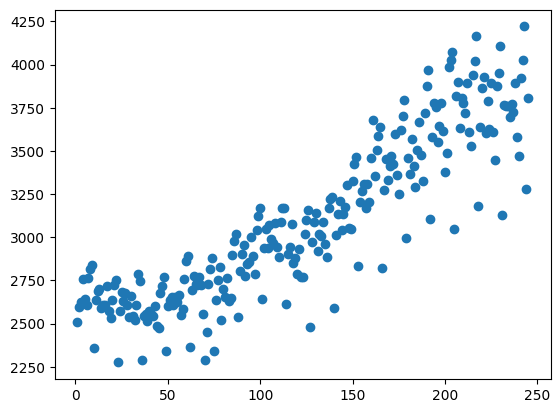

In [179]:
plt.scatter(xvals, yvals)
plt.show()

## 3b) Fit a linear model $f(x) = \beta_0 + \beta_1 x$ to the data

- Print the values of the regression coefficients $\beta_0, \beta_1$ determined using least-squares. 
- Plot the fitted model and the scatterplot on the same plot.
- Compute and print the **MSE** and the $R^2$ coefficient for the fitted model.

All numerical outputs should be displayed to three decimal places.

beta1 =  2367.3817664770813 and beta2 =  5.938990118238408
MSE =  45323.63592122835  and R^2 =  0.7956113333574003


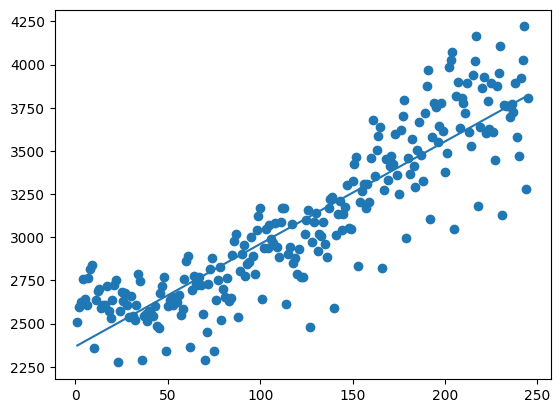

In [180]:
X = np.column_stack(( np.ones((N, 1)) , xvals))
XT = X.T
beta = np.linalg.inv(XT.dot(X)).dot(XT).dot(yvals)
fit = X.dot(beta)
print("beta1 = " ,beta[0], "and beta2 = " , beta[1])
plt.scatter(xvals, yvals)
plt.plot(xvals ,fit )
SSE = np.linalg.norm(yvals - fit)**2
MSE = SSE/N
R2 = 1- MSE /np.var(yvals)
print("MSE = ", MSE , " and R^2 = ", R2)


## 3c)  Plotting the residuals

- Plot the residuals on a scatterplot
- Also plot the residuals over a short duration and comment on whether you can discern any periodic components.

the figure on the right shows what one period look like so T = 149-135 =14


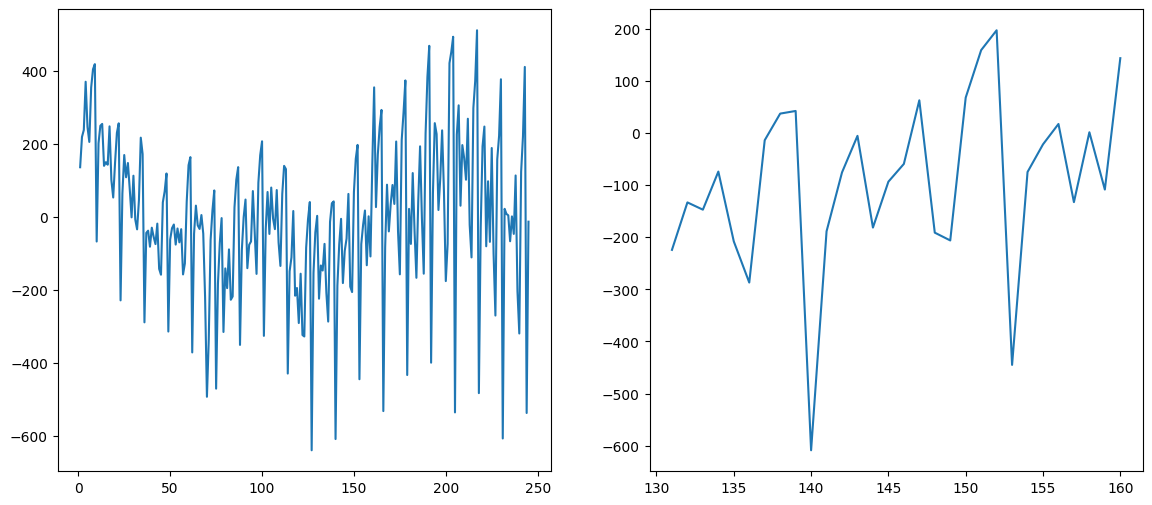

In [181]:
res = yvals - fit
plt.figure(figsize=(14, 6)) 
plt.subplot(121)
plt.plot(xvals ,res )
plt.subplot(122)
plt.plot(xvals[130:160],res[130:160])
print("the figure on the right shows what one period look like so T = 149-135 =14")


< Comment on periodic components here >

In [182]:
print("the figure on the right shows what one period look like so T = 149-135 =14")


the figure on the right shows what one period look like so T = 149-135 =14


### 3d) Periodogram

- Compute and plot the peridogram of the residuals. (Recall that the periodogram is the squared-magnitude of the DFT coefficients.)
- Identify the indices/frequencies for which the periogram value exceeds **50%** of the maximum. 


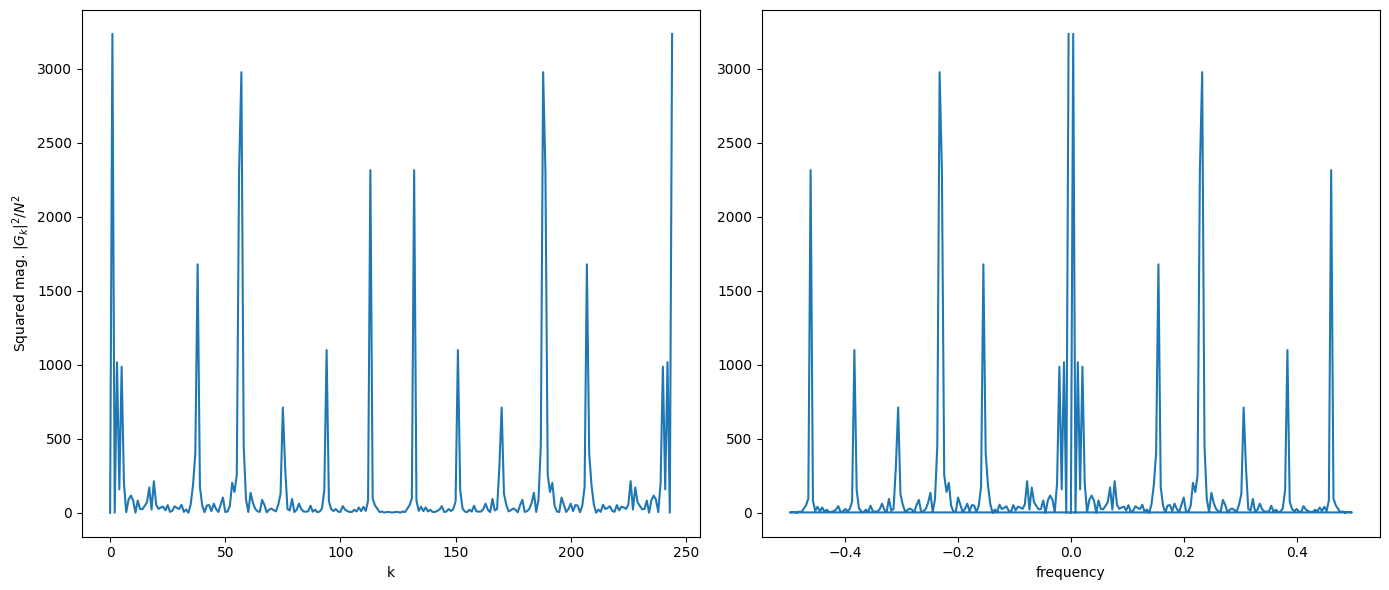

In [183]:
pgram = np.abs(np.fft.fft(res, N)/N)**2 
indices = np.linspace(0, (N-1), num = N)
freqs_in_hz = np.fft.fftfreq(N)
freqs_in_rads = freqs_in_hz*2*math.pi

plt.figure(figsize=(14, 6)) 
plt.subplot(121)
plt.plot(indices, pgram)
plt.xlabel('k')
plt.ylabel('Squared mag. $|G_k|^2/N^2$')
plt.subplot(122)
plt.plot(freqs_in_hz, pgram)
plt.xlabel('frequency')  
plt.savefig('DFT_CO2.pdf', bbox_inches = 'tight')
plt.tight_layout()


In [184]:
top_inds = indices[(pgram > 0.5*np.max(pgram))]
top_angularfreqs = freqs_in_rads[(pgram > 0.5*np.max(pgram) )]

print('Top indices:', top_inds, ' Top frequencies:', top_angularfreqs)


Top indices: [  1.  38.  56.  57. 113. 132. 188. 189. 207. 244.]  Top frequencies: [ 0.02564565  0.97453486  1.43615664  1.4618023   2.89795894 -2.89795894
 -1.4618023  -1.43615664 -0.97453486 -0.02564565]


## 3e) To the residuals,  fit a model of the form  

$$ \beta_{1s} \sin(\omega_1 x) + \beta_{1c} \cos(\omega_1 x) + \beta_{2s} \sin(\omega_2 x) + \beta_{2c} \cos(\omega_2 x) + \ldots + \beta_{Ks} \sin(\omega_K x) + \beta_{Kc} \cos(\omega_K x).$$

The frequencies $\omega_1, \ldots, \omega_K$ in the model are those corresponding to the indices identified in Part 2c. (Hint: Each of the sines and cosines will correspond to one column in your X-matrix.)

- Print the values of the regression coefficients obtained using least-squares. 

All numerical outputs should be displayed to three decimal places.


In [185]:
# Your code here
ws = top_angularfreqs[:len(top_angularfreqs) // 2]
XT2 = np.vstack((np.sin(ws[0]*xvals), np.cos(ws[0]*xvals)))
for i in range(len(ws)-1) :
    XT2 = np.vstack((XT2, np.sin(ws[i+1]*xvals), np.cos(ws[i+1]*xvals)))
X2 = np.transpose(XT2)
beta_sc = np.linalg.inv(XT2.dot(X2)).dot(XT2).dot(res)
print("Regression coefficients:", np.round(beta_sc, 3))

Regression coefficients: [-51.253 101.556  61.628 -54.006 -15.581 -94.797  81.659  72.381  32.472
  90.589]


### 3f) The combined fit
- Plot the combined fit together with a scatterplot of the data
- Compute and print the final **MSE** and $R^2$ coefficient. Comment on the improvement over the linear fit.

The combined fit, which corresponds to the full model

$$
f(x) = \beta_0 + \beta_1 x + \beta_{s1} \sin(\omega_1 x) + \beta_{c1} \cos(\omega_1 x) + \ldots + \beta_{sk} \sin(\omega_k x) + \beta_{ck} \cos(\omega_k x),
$$

can be obtained by adding the fits in parts 2b) and 2e).

MSE =  20297.501187772497  and R^2 =  0.9084676434354129


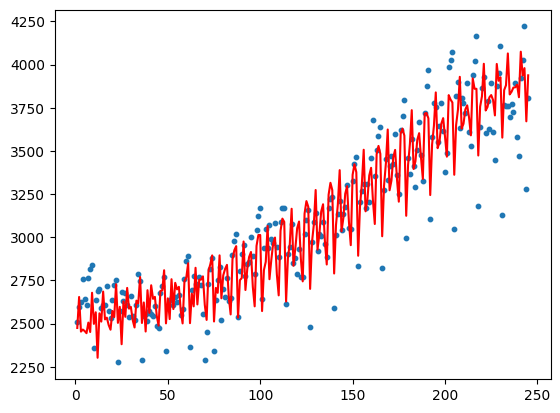

In [186]:
final_fit = X.dot(beta) + X2.dot(beta_sc)
plt.plot(xvals ,final_fit, "r" )
plt.scatter(xvals, yvals , s=10 )
error = yvals-final_fit
SSE = np.linalg.norm(error)**2
MSE = SSE/N
R2 = 1- MSE /np.var(yvals)
print("MSE = ", MSE , " and R^2 = ", R2)



< Add comment on the improvement over the linear fit. >

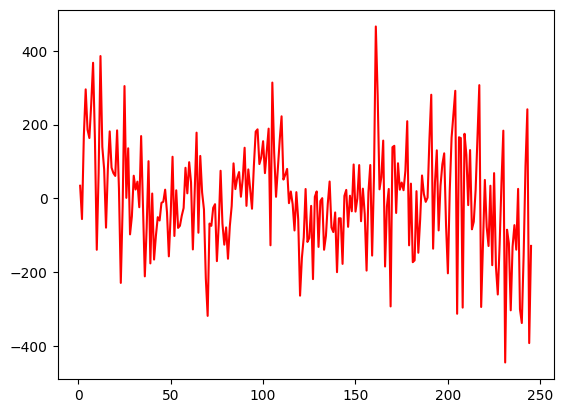

In [187]:
#if we add more sine values of frequencies with smaller magnitude, we can improve our model. also we can include linear parts like y = ax+b to have a better prediction.
#if we decrease the freshhold for frequencies to 10%, we get R^2 of 0.95 instesd of 0.9
plt.plot(xvals ,error, "r" )
